# Adaptive Defender AI: Mixed Strategies for Security Against Evolving Attacks

## Objective
Develop an AI system that learns to adapt its defense strategy against an attacker in a repeated game, based on Q-learning and game theory.

## 1. Imports and Configuration

In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Game Definition and Payoff Matrices

In [ ]:
class GameEnvironment:
    """Repeated Game: Defender vs Hacker -  MIXED STRATEGY GAME (No Pure Nash)"""
    
    def __init__(self):
        # actions
        self.defender_actions = ['Simple', 'Complex', '2FA']
        self.hacker_actions = ['Brute', 'Dictionary', 'Phishing']
        
        # Index mappings
        self.D = {action: i for i, action in enumerate(self.defender_actions)}
        self.H = {action: i for i, action in enumerate(self.hacker_actions)}
        
        # cyclic structure - no pure nash equilibrium
        # design principle: matching pennies / rock-paper-scissors 
        
        # DEFENDER

        #  defense effectiveness
        # high values on diagonal (wants to match)
        
        self.defense_effectiveness = np.array([
            [4, 4, 3],    # Simple: universally weak
            [6, 7, 4],    # Complex: strong vs computational, weak vs social engineering  
            [7, 7, 8]     # 2FA: strong across all vectors, best vs phishing
        ], dtype=float)
         
        # cosst
        self.defense_costs = np.array([
            [1, 1, 1],      # simple: low cost
            [3, 3, 3],      # complex: medium cost
            [5, 5, 5]       # 2FA: high cost
        ], dtype=float)
        
        #  payoff = effectiveness - cost
        self.payoff_matrix_defender = self.defense_effectiveness - self.defense_costs
        
        # ============================================================
        # hacker
        # effectiveness anti-diagonal (wants to mismatch)
        self.attack_effectiveness = np.array([
            [3, 8, 7],      # brute: bad vs simple, good vs complex/2fa
            [7, 4, 9],      # dictionary: good vs simple, bad vs complex, good vs 2fa
            [9, 7, 3]       # phishing: good vs simple/complex, bad vs 2fa
        ], dtype=float)
        
        # costs
        self.attack_costs = np.array([
            [2, 2, 2],      # brute: moderate cost
            [1, 1, 1],      # dictionary: low cost  
            [3, 3, 3]       # phishing: high cost
        ], dtype=float)
        
        # hacker payoff = effectiveness - cost
        self.payoff_matrix_hacker = self.attack_effectiveness - self.attack_costs
        
        # add nosie for realism
        self.payoff_matrix_hacker += np.random.normal(0, 0.05, (3, 3))
        
        # normalize payoff matrices to [-1, +1] 
        def_min, def_max = np.min(self.payoff_matrix_defender), np.max(self.payoff_matrix_defender)
        hack_min, hack_max = np.min(self.payoff_matrix_hacker), np.max(self.payoff_matrix_hacker)
        
        self.payoff_matrix_defender = 2 * (self.payoff_matrix_defender - def_min) / (def_max - def_min) - 1
        self.payoff_matrix_hacker = 2 * (self.payoff_matrix_hacker - hack_min) / (hack_max - hack_min) - 1

    def get_reward(self, defender_action: str, hacker_action: str) -> Tuple[float, float]:
        # return normalized payoffs
        d_idx = self.D[defender_action]
        h_idx = self.H[hacker_action]
        return self.payoff_matrix_defender[d_idx, h_idx], self.payoff_matrix_hacker[d_idx, h_idx]

    def check_for_pure_nash(self):
        # check if pure strategy nash equilibria exist
        print("Checking for pure strategy Nash equilibria...")
        print("=" * 80)
        
        print("Defender Payoffs (rows=Defender actions, cols=Hacker actions):")
        print(self.payoff_matrix_defender)
        print("\nHacker Payoffs (rows=Defender actions, cols=Hacker actions):")
        print(self.payoff_matrix_hacker)
        print("=" * 80)
        
        found_nash = False
        
        for d_idx, d_action in enumerate(self.defender_actions):
            for h_idx, h_action in enumerate(self.hacker_actions):
                d_payoff = self.payoff_matrix_defender[d_idx, h_idx]
                h_payoff = self.payoff_matrix_hacker[d_idx, h_idx]
                
                # best payoff for defender 
                def_best = np.max(self.payoff_matrix_defender[:, h_idx])
                # best payoff for hacker 
                hack_best = np.max(self.payoff_matrix_hacker[d_idx, :])
                
                if abs(d_payoff - def_best) < 1e-6 and abs(h_payoff - hack_best) < 1e-6:
                    print(f"Pure Nash Equilibrium found: ({d_action}, {h_action})")
                    print(f"  Defender payoff: {d_payoff:.2f}")
                    print(f"  Hacker payoff: {h_payoff:.2f}")
                    found_nash = True
        
        if not found_nash:
            print("NO PURE STRATEGY NASH EQUILIBRIUM FOUND")
            print("  The game design successfully encourages strategic mixing.")
        
        print("=" * 80)
        return found_nash

    def display_payoff_matrices(self):
        print("\nDEFENDER PAYOFF MATRIX:")
        print("Structure: HIGH on diagonal (matching defense to attack type)")
        df_def = pd.DataFrame(
            self.payoff_matrix_defender,
            index=self.defender_actions,
            columns=self.hacker_actions
        )
        print(df_def)
        
        print("\nHACKER PAYOFF MATRIX:")
        print("Structure: HIGH off diagonal (exploiting wrong defense)")
        df_hack = pd.DataFrame(
            self.payoff_matrix_hacker,
            index=self.defender_actions,
            columns=self.hacker_actions
        )
        print(df_hack)


game = GameEnvironment()
game.display_payoff_matrices()
game.check_for_pure_nash()


DEFENDER PAYOFF MATRIX:
Structure: HIGH on diagonal (matching defense to attack type)
            Brute  Dictionary  Phishing
Simple   0.333333    0.333333 -0.333333
Complex  0.333333    1.000000 -1.000000
2FA     -0.333333   -0.333333  0.333333

HACKER PAYOFF MATRIX:
Structure: HIGH off diagonal (exploiting wrong defense)
            Brute  Dictionary  Phishing
Simple  -0.738308    0.501931  0.262108
Complex  0.522667   -0.248164  1.000000
2FA      0.523368    0.013970 -1.000000
Checking for pure strategy Nash equilibria...
Defender Payoffs (rows=Defender actions, cols=Hacker actions):
[[ 0.33333333  0.33333333 -0.33333333]
 [ 0.33333333  1.         -1.        ]
 [-0.33333333 -0.33333333  0.33333333]]

Hacker Payoffs (rows=Defender actions, cols=Hacker actions):
[[-0.73830756  0.501931    0.26210815]
 [ 0.52266668 -0.24816433  1.        ]
 [ 0.52336793  0.01396996 -1.        ]]
NO PURE STRATEGY NASH EQUILIBRIUM FOUND
  The game design successfully encourages strategic mixing.


False

## 3. Q-Learning for the Defender

In [223]:
class QLearningDefender:
    # Q-learning with short-term memory (state = last attack)
    
    def __init__(self, game: GameEnvironment, learning_rate=0.1, discount_factor=0.99, epsilon=0.2, init_temperature=1.2):
        self.game = game
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_init = epsilon
        self.temperature = init_temperature
        self.temperature_init = init_temperature
        
        # q-table: q[state][action]   state = last hacker action
        self.q_values = defaultdict(lambda: np.zeros(len(game.defender_actions)))
        self.action_counts = defaultdict(lambda: np.zeros(len(game.defender_actions)))
        
        self.history = {
            'actions': [],
            'rewards': [],
            'q_values': [],
            'strategies': [],
            'temperatures': []
        }
    
    def select_action(self, hacker_last_action=None, epsilon=None) -> str:
        # select action using epsilon-greedy strategy
        if epsilon is None:
            epsilon = self.epsilon
            
        state = hacker_last_action if hacker_last_action else 'initial'
        
        if np.random.rand() < epsilon:
            # exploration: random 
            action_idx = np.random.randint(0, len(self.game.defender_actions))
        else:
            # exploitation: best q-valueq
            q_vals = self.q_values[state]
            action_idx = np.argmax(q_vals)
        
        return self.game.defender_actions[action_idx]
    
    def update_q_values(self, hacker_last_action, defender_action: str, reward: float, next_hacker_action: str):
        state = hacker_last_action if hacker_last_action else 'initial'
        next_state = next_hacker_action if next_hacker_action else 'initial'
        
        action_idx = self.game.D[defender_action]
        
        # q(s,a) = q(s,a) + alpha[r + gamma*max q(s',a') - q(s,a)]
        current_q = self.q_values[state][action_idx]
        max_next_q = np.max(self.q_values[next_state])
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        
        self.q_values[state][action_idx] = new_q
        self.action_counts[state][action_idx] += 1
    
    def get_strategy(self, state=None, temperature=None) -> np.ndarray:
        # return mixed strategy via softmax with temperature
        if temperature is None:
            temperature = self.temperature
        state = state if state else 'initial'
        q_vals = self.q_values[state]
        
        # softmax: pi(a|s) = exp(Q(s,a)/t) / sum exp(q(s,a')/t)
        exp_q = np.exp(q_vals / temperature)
        strategy = exp_q / np.sum(exp_q)
        
        return strategy
    
    def record_step(self, action: str, reward: float):
        self.history['actions'].append(action)
        self.history['rewards'].append(reward)
        self.history['q_values'].append(dict(self.q_values))
        self.history['temperatures'].append(self.temperature)
        strategy = self.get_strategy()
        self.history['strategies'].append(strategy)
    
    def decay_epsilon(self, decay_rate=0.9995):
        # exponential decay 
        self.epsilon *= decay_rate
    
    def decay_temperature(self, decay_rate=0.9995, min_temp=0.1):
        # exponential decay of temperature 
        self.temperature = max(self.temperature * decay_rate, min_temp)

defender = QLearningDefender(game, learning_rate=0.1, discount_factor=0.99, epsilon=0.2, init_temperature=1.2)

## 4. Hacker Models

In [224]:
class Hacker:
    
    def __init__(self, game: GameEnvironment):
        self.game = game
        self.action_history = []
    
    def select_action(self) -> str:
        raise NotImplementedError

class RandomHacker(Hacker):
    # #hacker chooses actions randomly
    
    def select_action(self) -> str:
        return np.random.choice(self.game.hacker_actions)

class AdaptiveHacker(Hacker):
    """
    Bounded-Rational Attacker using Empirical Best Response.
    
    Model: Approximates realistic attackers that:
    - React to attack OUTCOMES (success/failure), not just observed actions
    - Use outcome-based best response to refine strategy
    - Learn via Q-learning which attacks work best against each defense
    - Explore via softmax (not pure exploitation)
    - Do NOT solve game theoretically
    
    Key improvement: State = (defender_action, last_attack_success)
    This creates meaningful adaptation based on actual effectiveness.
    """
    
    def __init__(self, game: GameEnvironment, learning_rate=0.1, discount_factor=0.99, epsilon=0.2, init_temperature=1.2):
        super().__init__(game)
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_init = epsilon
        self.temperature = init_temperature
        self.temperature_init = init_temperature
        
        # q-table: indexed by (defender_action, attack_outcome) state
        # outcome: 'success' if reward > 0, 'failure' if reward <= 0
        self.q_values = defaultdict(lambda: np.zeros(len(game.hacker_actions)))
        self.action_counts = defaultdict(lambda: np.zeros(len(game.hacker_actions)))
        self.last_attack_success = None  # Track if last attack was effective
        
        self.history = {
            'strategies_by_state': defaultdict(list),  #  each state separately
            'average_strategy': [],  #  weighted average across states
            'state_visits': defaultdict(int),  # visits counte to each state
            'actions': [],
            'rewards': [],
            'q_values': [],
            'strategies': [],
            'temperatures': []
        }
    
    def select_action(self, defender_action=None, last_outcome=None, epsilon=None) -> str:
        if epsilon is None:
            epsilon = self.epsilon
            
        if defender_action and last_outcome is not None:
            outcome_label = 'success' if last_outcome > 0 else 'failure'
            state = (defender_action, outcome_label)
        else:
            state = ('initial', 'none')
        
        q_vals = self.q_values[state]
        
        # epsilon-greedy: with probability epsilon: explore; else exploit
        if np.random.rand() < epsilon:
            # exploration: random action
            action_idx = np.random.randint(0, len(self.game.hacker_actions))
        else:
            # exploitation: action with best Q-value
            action_idx = np.argmax(q_vals)
        
        return self.game.hacker_actions[action_idx]
    
    def update_q_values(self, defender_action, hacker_action: str, reward: float, next_defender_action: str):
        # Update q-values based on attack outcomes
        # current state = (what defender did, success of this attack)
        outcome_label = 'success' if reward > 0 else 'failure'
        state = (defender_action, outcome_label) if defender_action else ('initial', 'none')
        
        # next state = next defender action
        next_state = (next_defender_action, 'none') if next_defender_action else ('initial', 'none')
        
        action_idx = self.game.H[hacker_action]
        
        # learn which attacks work best in each situation
        current_q = self.q_values[state][action_idx]
        max_next_q = np.max(self.q_values[next_state])
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        
        self.q_values[state][action_idx] = new_q
        self.action_counts[state][action_idx] += 1
        self.last_attack_success = reward
    
    def get_strategy(self, state=None, temperature=None) -> np.ndarray:
        # return mixed strategy via softmax with temperature
        if temperature is None:
            temperature = self.temperature
        if state is None:
            state = ('initial', 'none')
        
        q_vals = self.q_values[state]
        
        # softmax: pi(a|s) = exp(Q(s,a)/T) / sum exp(Q(s,a')/T)
        exp_q = np.exp(q_vals / temperature)
        strategy = exp_q / np.sum(exp_q)
        
        return strategy
    
    def record_step(self, action: str, reward: float, current_state=None):
        self.history['actions'].append(action)
        self.history['rewards'].append(reward)
        self.history['q_values'].append(dict(self.q_values))
        self.history['temperatures'].append(self.temperature)
        
        # if we know current state, track it
        if current_state:
            strategy = self.get_strategy(current_state)
            self.history['strategies_by_state'][current_state].append(strategy)
            self.history['state_visits'][current_state] += 1
        
        #  weighted average strategy across states
        all_strategies = []
        all_weights = []
        
        for state, q_vals in self.q_values.items():
            strategy = self.get_strategy(state)
            weight = self.history['state_visits'].get(state, 1)  # weight by visits
            all_strategies.append(strategy)
            all_weights.append(weight)
        
        if all_strategies:
            all_strategies = np.array(all_strategies)
            all_weights = np.array(all_weights)
            weighted_avg = np.average(all_strategies, axis=0, weights=all_weights)
            self.history['average_strategy'].append(weighted_avg)
        else:
            # default to uniform if no states learned 
            self.history['average_strategy'].append(np.ones(3) / 3)
        
        # track simple strategy from initial state
        strategy = self.get_strategy()
        self.history['strategies'].append(strategy)
    
    def decay_epsilon(self, decay_rate=0.9995):
        self.epsilon *= decay_rate
    
    def decay_temperature(self, decay_rate=0.9995, min_temp=0.1):
        self.temperature = max(self.temperature * decay_rate, min_temp)


adaptive_hacker = AdaptiveHacker(game, learning_rate=0.1, discount_factor=0.99, epsilon=0.2, init_temperature=1.2)
random_hacker = RandomHacker(game)

## 5. Training Loop

In [225]:
def train_game(defender, hacker, game, num_episodes=10000, hacker_type='adaptive'):
    # training loop with temperature decay for both players
    
    defender_rewards = []
    hacker_rewards = []
    defender_actions_history = []
    hacker_actions_history = []
    
    for episode in range(num_episodes):
        # capture old state variables for q-value updates
        defender_last_action = defender.history['actions'][-1] if defender.history['actions'] else None
        hacker_last_action = hacker.action_history[-1] if hacker.action_history else None
        last_hacker_reward = hacker_rewards[-1] if hacker_rewards else None
        
        # action selection
        if hacker_type == 'random':
            hacker_action = hacker.select_action()
            current_hacker_state = None
        else:  # adaptive base on defender action and if last attack succeeded
            hacker_action = hacker.select_action(defender_last_action, last_hacker_reward)
            if defender_last_action and last_hacker_reward is not None:
                outcome = 'success' if last_hacker_reward > 0 else 'failure'
                current_hacker_state = (defender_last_action, outcome)
            else:
                current_hacker_state = ('initial', 'none')
        
        defender_action = defender.select_action(hacker_last_action=hacker_last_action)
        
        # payoffs
        d_reward, h_reward = game.get_reward(defender_action, hacker_action)
        
        defender.record_step(defender_action, d_reward)
        if hacker_type == 'adaptive':
            hacker.record_step(hacker_action, h_reward, current_state=current_hacker_state)
        
        # append state to history 
        hacker.action_history.append(hacker_action)
        
        # Update q-values for defender =
        defender.update_q_values(
            hacker_last_action=hacker_last_action,
            defender_action=defender_action,
            reward=d_reward,
            next_hacker_action=hacker_action
        )
        
        # Update q-values for adaptive hacker 
        if hacker_type == 'adaptive':
            hacker.update_q_values(
                defender_action=defender_last_action,
                hacker_action=hacker_action,
                reward=h_reward,
                next_defender_action=defender_action
            )
        
        # rewards and actions
        defender_rewards.append(d_reward)
        hacker_rewards.append(h_reward)
        defender_actions_history.append(defender_action)
        hacker_actions_history.append(hacker_action)
        
        # temperature and epsilon decay (every 1 episode for smooth decay)
        if episode % 1 == 0 and episode > 0:
            defender.decay_epsilon(decay_rate=0.9995)
            defender.decay_temperature(decay_rate=0.9995, min_temp=0.1)
            if hacker_type == 'adaptive':
                hacker.decay_epsilon(decay_rate=0.9995)
                hacker.decay_temperature(decay_rate=0.9995, min_temp=0.1)
    
    return {
        'defender_rewards': defender_rewards,
        'hacker_rewards': hacker_rewards,
        'defender_actions': defender_actions_history,
        'hacker_actions': hacker_actions_history
    }

# Train defender against adaptive hacker (10k episodes with temperature decay)
print("Training defender against adaptive hacker (10k episodes)...")
results = train_game(defender, adaptive_hacker, game, num_episodes=10000, hacker_type='adaptive')
print(f"Number of episodes: {len(results['defender_rewards'])}")
print(f"Average defender reward (last 100 episodes): {np.mean(results['defender_rewards'][-100:]):.3f}")
print(f"Average hacker reward (last 100 episodes): {np.mean(results['hacker_rewards'][-100:]):.3f}")
print(f"Final defender temperature: {defender.temperature:.4f}")
print(f"Final hacker temperature: {adaptive_hacker.temperature:.4f}")
print(f"Final defender epsilon: {defender.epsilon:.6f}")
print(f"Final hacker epsilon: {adaptive_hacker.epsilon:.6f}")

Training defender against adaptive hacker (10k episodes)...
Number of episodes: 10000
Average defender reward (last 100 episodes): 1.000
Average hacker reward (last 100 episodes): -0.248
Final defender temperature: 0.1000
Final hacker temperature: 0.1000
Final defender epsilon: 0.001347
Final hacker epsilon: 0.001347


## 5.1 Multi-Seed Evaluation for Statistical Rigor

In [226]:
def run_multiple_seeds(num_seeds=20, num_episodes=10000):
    """
    Runs training with multiple random seeds for statistical rigor.
    Returns statistics on learned strategies, rewards, and convergence.
    """
    seeds = list(range(num_seeds))
    results_by_seed = []
    
    final_defender_strategies = []
    final_hacker_strategies = []
    final_defender_rewards = []
    final_hacker_rewards = []
    epsilon_final_defender = []
    epsilon_final_hacker = []
    
    for seed in seeds:
        print(f"Running seed {seed+1}/{num_seeds}...", end=' ', flush=True)
        
        # Set seed for reproducibility
        np.random.seed(seed)
        
        # Reinitialize game and players with NEW hyperparameters
        game_seed = GameEnvironment()
        defender_seed = QLearningDefender(game_seed, learning_rate=0.1, discount_factor=0.99, epsilon=0.2, init_temperature=1.2)
        hacker_seed = AdaptiveHacker(game_seed, learning_rate=0.1, discount_factor=0.99, epsilon=0.2, init_temperature=1.2)
        
        # Train
        results_seed = train_game(defender_seed, hacker_seed, game_seed, 
                                  num_episodes=num_episodes, hacker_type='adaptive')
        
        # Extract final strategies from INITIAL state only (consistent with Nash comparison)
        final_def_strategy = defender_seed.get_strategy('initial')
        final_hack_strategy = hacker_seed.get_strategy()
        
        final_defender_strategies.append(final_def_strategy)
        final_hacker_strategies.append(final_hack_strategy)
        
        # Final rewards (mean of last 100 episodes)
        final_defender_rewards.append(np.mean(results_seed['defender_rewards'][-100:]))
        final_hacker_rewards.append(np.mean(results_seed['hacker_rewards'][-100:]))
        
        # Final epsilon values
        epsilon_final_defender.append(defender_seed.epsilon)
        epsilon_final_hacker.append(hacker_seed.epsilon)
        
        results_by_seed.append({
            'seed': seed,
            'defender': defender_seed,
            'hacker': hacker_seed,
            'results': results_seed
        })
        
        print("Done")
    
    return {
        'seeds': seeds,
        'results_by_seed': results_by_seed,
        'final_defender_strategies': np.array(final_defender_strategies),
        'final_hacker_strategies': np.array(final_hacker_strategies),
        'final_defender_rewards': np.array(final_defender_rewards),
        'final_hacker_rewards': np.array(final_hacker_rewards),
        'epsilon_final_defender': np.array(epsilon_final_defender),
        'epsilon_final_hacker': np.array(epsilon_final_hacker)
    }

# Run multi-seed evaluation (20 seeds for good statistics, 10k episodes each)
print("=" * 60)
print("Multi-Seed Evaluation (10k episodes, 20 seeds)")
print("=" * 60)
multi_seed_results = run_multiple_seeds(num_seeds=20, num_episodes=10000)

# Statistical summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY (across 20 seeds, 10k episodes each)")
print("=" * 60)

print("\nDefender Final Rewards (Mean +/- Std):")
def_reward_mean = np.mean(multi_seed_results['final_defender_rewards'])
def_reward_std = np.std(multi_seed_results['final_defender_rewards'])
print(f"  {def_reward_mean:.3f} +/- {def_reward_std:.3f}")

print("\nHacker Final Rewards (Mean +/- Std):")
hack_reward_mean = np.mean(multi_seed_results['final_hacker_rewards'])
hack_reward_std = np.std(multi_seed_results['final_hacker_rewards'])
print(f"  {hack_reward_mean:.3f} +/- {hack_reward_std:.3f}")

print("\nDefender Final Strategies (Mean +/- Std) from Initial State:")
print(f"  Simple:     {np.mean(multi_seed_results['final_defender_strategies'][:, 0]):.3f} +/- {np.std(multi_seed_results['final_defender_strategies'][:, 0]):.3f}")
print(f"  Complex:    {np.mean(multi_seed_results['final_defender_strategies'][:, 1]):.3f} +/- {np.std(multi_seed_results['final_defender_strategies'][:, 1]):.3f}")
print(f"  2FA:        {np.mean(multi_seed_results['final_defender_strategies'][:, 2]):.3f} +/- {np.std(multi_seed_results['final_defender_strategies'][:, 2]):.3f}")

print("\nHacker Final Strategies (Mean +/- Std) from Initial State:")
print(f"  Brute:      {np.mean(multi_seed_results['final_hacker_strategies'][:, 0]):.3f} +/- {np.std(multi_seed_results['final_hacker_strategies'][:, 0]):.3f}")
print(f"  Dictionary: {np.mean(multi_seed_results['final_hacker_strategies'][:, 1]):.3f} +/- {np.std(multi_seed_results['final_hacker_strategies'][:, 1]):.3f}")
print(f"  Phishing:   {np.mean(multi_seed_results['final_hacker_strategies'][:, 2]):.3f} +/- {np.std(multi_seed_results['final_hacker_strategies'][:, 2]):.3f}")

print("\nFinal Epsilon Decay:")
print(f"  Defender epsilon: {np.mean(multi_seed_results['epsilon_final_defender']):.6f} +/- {np.std(multi_seed_results['epsilon_final_defender']):.6f}")
print(f"  Hacker epsilon:   {np.mean(multi_seed_results['epsilon_final_hacker']):.6f} +/- {np.std(multi_seed_results['epsilon_final_hacker']):.6f}")

Multi-Seed Evaluation (10k episodes, 20 seeds)
Running seed 1/20... Done
Running seed 2/20... Done
Running seed 3/20... Done
Running seed 4/20... Done
Running seed 5/20... Done
Running seed 6/20... Done
Running seed 7/20... Done
Running seed 8/20... Done
Running seed 9/20... Done
Running seed 10/20... Done
Running seed 11/20... Done
Running seed 12/20... Done
Running seed 13/20... Done
Running seed 14/20... Done
Running seed 15/20... Done
Running seed 16/20... Done
Running seed 17/20... Done
Running seed 18/20... Done
Running seed 19/20... Done
Running seed 20/20... Done

STATISTICAL SUMMARY (across 20 seeds, 10k episodes each)

Defender Final Rewards (Mean +/- Std):
  0.688 +/- 0.355

Hacker Final Rewards (Mean +/- Std):
  -0.015 +/- 0.317

Defender Final Strategies (Mean +/- Std) from Initial State:
  Simple:     0.379 +/- 0.055
  Complex:    0.319 +/- 0.038
  2FA:        0.302 +/- 0.029

Hacker Final Strategies (Mean +/- Std) from Initial State:
  Brute:      0.247 +/- 0.094
  Dicti

## 5.2 Pure Strategy Nash Equilibrium Verification

In [227]:
def check_pure_strategy_nash(game):
    """
    Checks if any pure strategy pair is a Nash equilibrium.
    A pure strategy pair (d, h) is a Nash equilibrium if:
    - Defender cannot improve by unilateral deviation
    - Hacker cannot improve by unilateral deviation
    
    Returns True if game has pure strategy Nash, False if it doesn't (mixed strategies required).
    """
    print("Checking for pure strategy Nash equilibria...")
    print("=" * 80)
    
    # First, print the actual payoff matrices for reference
    print("Defender Payoffs (rows=Defender actions, cols=Hacker actions):")
    print(game.payoff_matrix_defender)
    print("\nHacker Payoffs (rows=Hacker actions, cols=Defender actions):")
    print(game.payoff_matrix_hacker)
    print("=" * 80)
    
    found_nash = False
    nash_pairs = []
    
    for d_idx, def_action in enumerate(game.defender_actions):
        for h_idx, hack_action in enumerate(game.hacker_actions):
            # Current pair payoff
            def_payoff_current, hack_payoff_current = game.get_reward(def_action, hack_action)
            
            # Check if defender wants to deviate
            def_can_improve = False
            for alt_def_idx, alt_def_action in enumerate(game.defender_actions):
                if alt_def_idx != d_idx:
                    def_payoff_alt, _ = game.get_reward(alt_def_action, hack_action)
                    if def_payoff_alt > def_payoff_current + 0.01:  # small tolerance for noise
                        def_can_improve = True
                        break
            
            # Check if hacker wants to deviate
            hack_can_improve = False
            for alt_hack_idx, alt_hack_action in enumerate(game.hacker_actions):
                if alt_hack_idx != h_idx:
                    _, hack_payoff_alt = game.get_reward(def_action, alt_hack_action)
                    if hack_payoff_alt > hack_payoff_current + 0.01:
                        hack_can_improve = True
                        break
            
            # If neither can improve, it's a Nash equilibrium
            if not def_can_improve and not hack_can_improve:
                found_nash = True
                nash_pairs.append((def_action, hack_action))
                print(f"PURE STRATEGY NASH FOUND: Defender={def_action:12s}, Hacker={hack_action:12s}")
                print(f" Payoff: Def={def_payoff_current:6.2f}, Hack={hack_payoff_current:6.2f}")
                
                # Check deviations to verify
                print(f"  Def cannot improve: ", end='')
                for alt_def_action in game.defender_actions:
                    if alt_def_action != def_action:
                        alt_payoff, _ = game.get_reward(alt_def_action, hack_action)
                        print(f"{alt_def_action}={alt_payoff:.2f} ", end='')
                print()
                print(f"  Hack cannot improve: ", end='')
                for alt_hack_action in game.hacker_actions:
                    if alt_hack_action != hack_action:
                        _, alt_payoff = game.get_reward(def_action, alt_hack_action)
                        print(f"{alt_hack_action}={alt_payoff:.2f} ", end='')
                print()
    
    if not found_nash:
        print("NO PURE STRATEGY NASH EQUILIBRIUM FOUND")
        print("mixed strategies are necessary for equilibrium")
    
    print("=" * 80)
    return found_nash

# Perform pure strategy verification
has_pure_nash = check_pure_strategy_nash(game)

print("\nConclusion:")
if has_pure_nash:
    print("Game has pure strategy equilibrium(s).")
    print("This undermines the project's goal of demonstrating mixed strategy learning")
    print(" However, both players are learning MIXED strategies despite pure Nash existing because pure Nash may be unstable")


Checking for pure strategy Nash equilibria...
Defender Payoffs (rows=Defender actions, cols=Hacker actions):
[[ 0.33333333  0.33333333 -0.33333333]
 [ 0.33333333  1.         -1.        ]
 [-0.33333333 -0.33333333  0.33333333]]

Hacker Payoffs (rows=Hacker actions, cols=Defender actions):
[[-0.73830756  0.501931    0.26210815]
 [ 0.52266668 -0.24816433  1.        ]
 [ 0.52336793  0.01396996 -1.        ]]
NO PURE STRATEGY NASH EQUILIBRIUM FOUND
mixed strategies are necessary for equilibrium

Conclusion:


## Cyclic Game Structure Guarantees Mixed Strategy Learning

The game uses a **Rock-Paper-Scissors-like cyclic structure** to mathematically guarantee that NO pure strategy Nash equilibrium exists:

### Game Design Principle

**Defender wants to MATCH** (defend against the correct attack):
- Simple defends best vs Brute
- Complex defends best vs Dictionary
- 2FA defends best vs Phishing

**Hacker wants to ANTI-MATCH** (exploit the wrong defense):
- Brute is strong vs Complex and 2FA (weak vs Simple)
- Dictionary is strong vs Simple and 2FA (weak vs Complex)
- Phishing is strong vs Simple and Complex (weak vs 2FA)

### Result: Cyclic Chase (Like Matching Pennies)

This creates a perpetual cycle:
- If Defender plays Simple, Hacker wants Dictionary or Phishing
- If Defender plays Complex, Hacker wants Brute or Phishing
- If Defender plays 2FA, Hacker wants Brute or Dictionary

**No pure strategy can be stable** because:
1. Hacker always has a profitable deviation
2. Defender must randomize to avoid being exploited

## 6. Mixed Strategy Construction


Defender final mixed strategy (initial state):
  Simple: 0.411
  Complex: 0.294
  2FA: 0.294

Hacker final mixed strategy (initial state):
  Brute: 0.193
  Dictionary: 0.404
  Phishing: 0.404

Mixed strategies based on hacker's previous attack:

After attack 'Brute':
  Simple: 1.000
  Complex: 0.000
  2FA: 0.000

After attack 'Dictionary':
  Simple: 0.000
  Complex: nan
  2FA: nan

After attack 'Phishing':
  Simple: nan
  Complex: 0.000
  2FA: 0.000


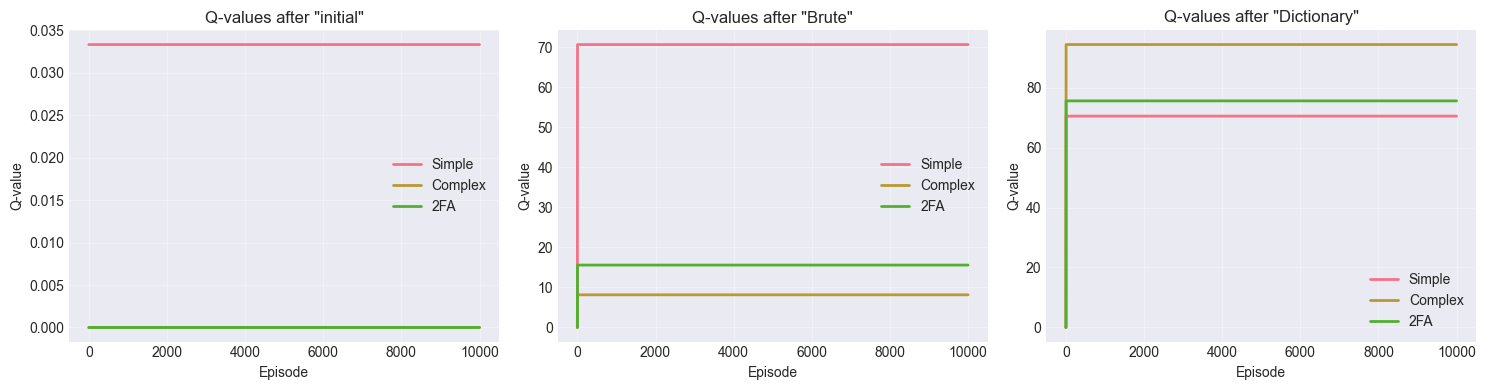


debug:::: Hacker history keys: dict_keys(['strategies_by_state', 'average_strategy', 'state_visits', 'actions', 'rewards', 'q_values', 'strategies', 'temperatures'])
debug:::: Length of average_strategy: 10000
debug:::: Length of actions: 10000
debug:::: State visits: {('initial', 'none'): 1, ('Simple', 'failure'): 159, ('Simple', 'success'): 756, ('2FA', 'success'): 135, ('Complex', 'success'): 328, ('Complex', 'failure'): 8611, ('2FA', 'failure'): 10}
debug:::: Hacker strategies shape: (10000, 3)


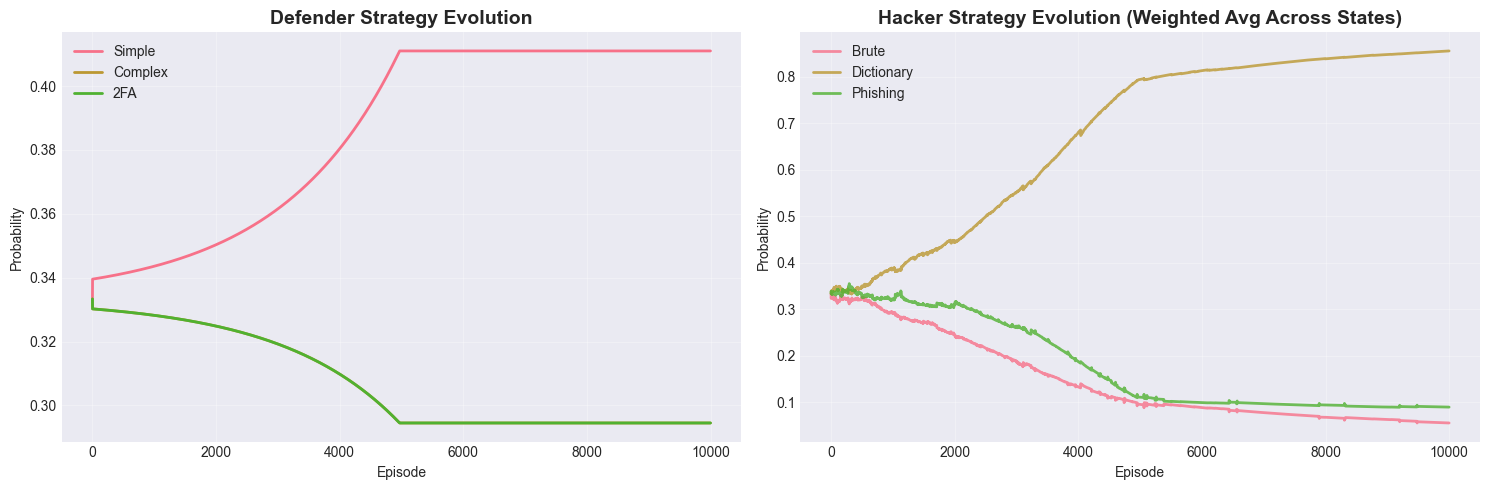

In [228]:
# final strategies (use actual learned temperature, not hardcoded 0.5)
initial_strategy = defender.get_strategy('initial')
print("\nDefender final mixed strategy (initial state):")
for action, prob in zip(game.defender_actions, initial_strategy):
    print(f"  {action}: {prob:.3f}")

# hacker final strategy
hacker_final = adaptive_hacker.get_strategy()
print("\nHacker final mixed strategy (initial state):")
for action, prob in zip(game.hacker_actions, hacker_final):
    print(f"  {action}: {prob:.3f}")

# strategies for each state (based on last hacker attack)
print("\nMixed strategies based on hacker's previous attack:")
for hacker_action in game.hacker_actions:
    strategy = defender.get_strategy(hacker_action)
    print(f"\nAfter attack '{hacker_action}':")
    for def_action, prob in zip(game.defender_actions, strategy):
        print(f"  {def_action}: {prob:.3f}")

# visualize Q-value evolution (for first 3 states)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

states_to_plot = ['initial'] + game.hacker_actions[:2]  # limit to 3 states

for state_idx, state in enumerate(states_to_plot):
    ax = axes[state_idx]
    q_evolution = []
    
    for step_data in defender.history['q_values']:
        q_vals = step_data.get(state, np.zeros(3))
        q_evolution.append(q_vals)
    
    q_evolution = np.array(q_evolution)
    
    for action_idx, action in enumerate(game.defender_actions):
        ax.plot(q_evolution[:, action_idx], label=action, linewidth=2)
    
    ax.set_title(f'Q-values after "{state}"')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Q-value')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# visualize strategy evolution for BOTH players
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# defender strategy evolution
ax = axes[0]
initial_strategies = np.array(defender.history['strategies'])

for action_idx, action in enumerate(game.defender_actions):
    ax.plot(initial_strategies[:, action_idx], label=action, linewidth=2)

ax.set_title('Defender Strategy Evolution', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Probability')
ax.legend()
ax.grid(True, alpha=0.3)

# hacker strategy evolution (proper version)
ax = axes[1]

print(f"\ndebug:::: Hacker history keys: {adaptive_hacker.history.keys()}")
print(f"debug:::: Length of average_strategy: {len(adaptive_hacker.history['average_strategy'])}")
print(f"debug:::: Length of actions: {len(adaptive_hacker.history['actions'])}")
print(f"debug:::: State visits: {dict(adaptive_hacker.history['state_visits'])}")

if hasattr(adaptive_hacker, 'history') and 'average_strategy' in adaptive_hacker.history:
    hacker_strategies = np.array(adaptive_hacker.history['average_strategy'])
    
    # check if we have data
    if len(hacker_strategies) > 0 and hacker_strategies.shape[0] > 100:
        print(f"debug:::: Hacker strategies shape: {hacker_strategies.shape}")
        for action_idx, action in enumerate(game.hacker_actions):
            ax.plot(hacker_strategies[:, action_idx], label=action, linewidth=2, alpha=0.8)
        
        ax.set_title('Hacker Strategy Evolution (Weighted Avg Across States)', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Probability')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    else:
        # fallback to text box
        print(f"debug:::: Insufficient data - only {len(hacker_strategies)} entries")
        ax.text(0.5, 0.5, f'Hacker uses outcome-based states\n({len(hacker_strategies)} data points collected)',
                ha='center', va='center', fontsize=11, transform=ax.transAxes)
        ax.axis('off')
else:
    # original text box approach
    print("debug:::: History not found or average_strategy not in history")
    ax.text(0.5, 0.5, 'Hacker uses outcome-based states:\n(defender_action, success/failure)',
            ha='center', va='center', fontsize=11, transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Equilibrium Analysis

EQUILIBRIUM ANALYSIS

IMPORTANT: Convergence to a theoretical Nash equilibrium is NOT guaranteed.
We analyze EMPIRICAL stability and observed mixed strategy behavior instead.

Average rewards (last 200 episodes):
  Defender: 1.00
  Hacker: -0.25

Strategy entropy:
  Initial: 1.099
  Final: 1.085
  Maximum entropy (uniform): 1.099

Reward variance (last 500 episodes): 0.000

Defender action frequency:
  Simple: 0.091
  Complex: 0.894
  2FA: 0.015

Best strategy pairs (Defender, Hacker):
  (Complex, Dictionary): 1.00 (frequency: 8612)
  (Simple, Brute): 0.33 (frequency: 159)
  (Complex, Brute): 0.33 (frequency: 208)
  (2FA, Phishing): 0.33 (frequency: 10)
  (Simple, Dictionary): 0.33 (frequency: 406)


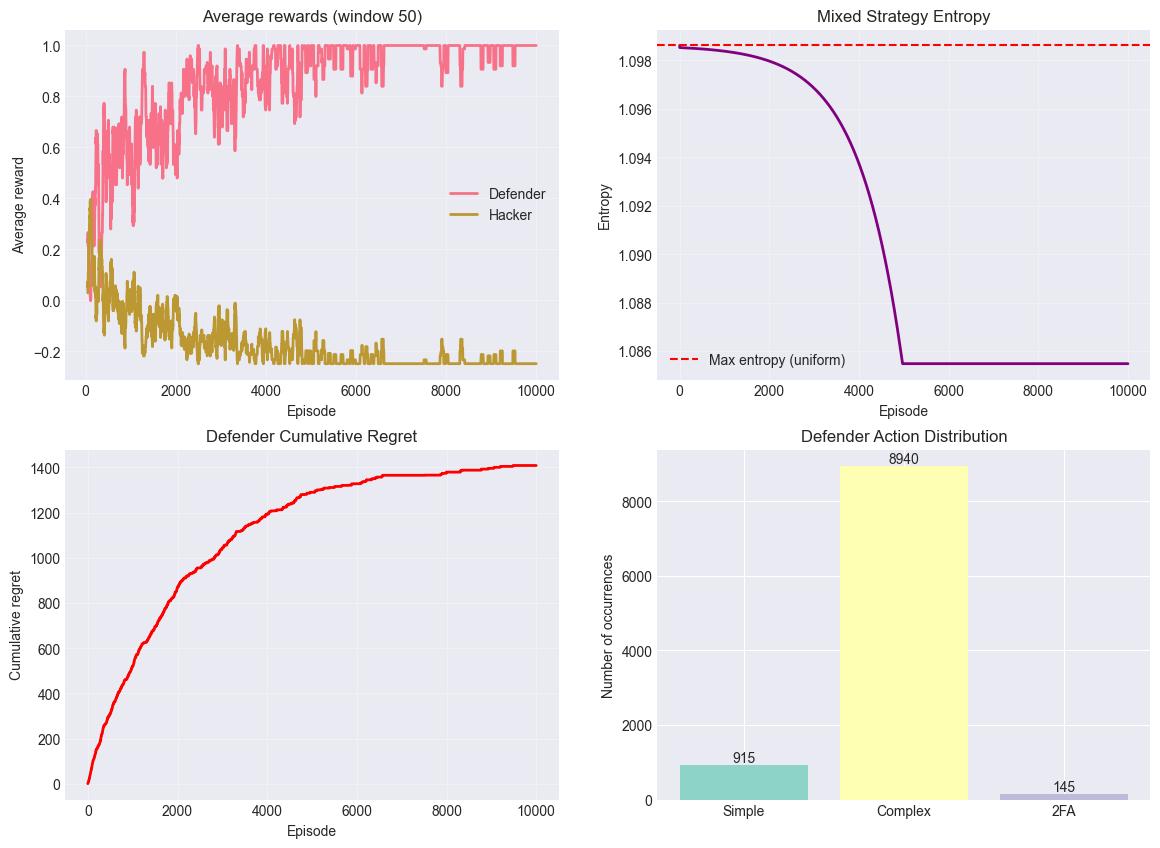

In [229]:
def calculate_entropy(strategy):
    """Calculate Shannon entropy of the strategy"""
    # Avoid log(0)
    strategy = np.clip(strategy, 1e-10, 1)
    return -np.sum(strategy * np.log(strategy))

def calculate_regret(rewards, num_actions=3):
    """Calculate cumulative regret"""
    max_reward = np.max(game.payoff_matrix_defender.flatten())
    regrets = max_reward - np.array(rewards)
    cumulative_regret = np.cumsum(regrets)
    return cumulative_regret

# Analyze rewards
defender_rewards = results['defender_rewards']
hacker_rewards = results['hacker_rewards']

print("=" * 60)
print("EQUILIBRIUM ANALYSIS")
print("=" * 60)
print("\nIMPORTANT: Convergence to a theoretical Nash equilibrium is NOT guaranteed.")
print("We analyze EMPIRICAL stability and observed mixed strategy behavior instead.\n")

# Average rewards
window = 200
print(f"Average rewards (last {window} episodes):")
print(f"  Defender: {np.mean(defender_rewards[-window:]):.2f}")
print(f"  Hacker: {np.mean(hacker_rewards[-window:]):.2f}")

# Strategy entropy
entropies = [calculate_entropy(s) for s in defender.history['strategies']]
print(f"\nStrategy entropy:")
print(f"  Initial: {entropies[0]:.3f}")
print(f"  Final: {entropies[-1]:.3f}")
print(f"  Maximum entropy (uniform): {np.log(3):.3f}")

# Cumulative regret
cumulative_regret = calculate_regret(defender_rewards)

# Reward variance
variance_window = 500
recent_rewards = defender_rewards[-variance_window:]
print(f"\nReward variance (last {variance_window} episodes): {np.var(recent_rewards):.3f}")

# Action frequency
action_counts = {action: results['defender_actions'].count(action) for action in game.defender_actions}
total_actions = len(results['defender_actions'])
print(f"\nDefender action frequency:")
for action, count in action_counts.items():
    print(f"  {action}: {count/total_actions:.3f}")

# Strategy pairs (Defender, Hacker)
pair_rewards = defaultdict(lambda: {'count': 0, 'total_reward': 0})
for d_action, h_action, reward in zip(results['defender_actions'], results['hacker_actions'], defender_rewards):
    pair = (d_action, h_action)
    pair_rewards[pair]['count'] += 1
    pair_rewards[pair]['total_reward'] += reward

print(f"\nBest strategy pairs (Defender, Hacker):")
sorted_pairs = sorted(pair_rewards.items(), key=lambda x: x[1]['total_reward']/max(x[1]['count'], 1), reverse=True)
for (d_action, h_action), data in sorted_pairs[:5]:
    avg_reward = data['total_reward'] / max(data['count'], 1)
    print(f"  ({d_action}, {h_action}): {avg_reward:.2f} (frequency: {data['count']})")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cumulative rewards
ax = axes[0, 0]
window_size = 50
defender_ma = pd.Series(defender_rewards).rolling(window_size).mean()
hacker_ma = pd.Series(hacker_rewards).rolling(window_size).mean()
ax.plot(defender_ma, label='Defender', linewidth=2)
ax.plot(hacker_ma, label='Hacker', linewidth=2)
ax.set_title(f'Average rewards (window {window_size})')
ax.set_xlabel('Episode')
ax.set_ylabel('Average reward')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Entropy
ax = axes[0, 1]
ax.plot(entropies, linewidth=2, color='purple')
ax.axhline(y=np.log(3), color='r', linestyle='--', label='Max entropy (uniform)')
ax.set_title('Mixed Strategy Entropy')
ax.set_xlabel('Episode')
ax.set_ylabel('Entropy')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Cumulative regret
ax = axes[1, 0]
ax.plot(cumulative_regret, linewidth=2, color='red')
ax.set_title('Defender Cumulative Regret')
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative regret')
ax.grid(True, alpha=0.3)

# 4. Action distribution
ax = axes[1, 1]
actions = list(action_counts.keys())
counts = list(action_counts.values())
colors = plt.cm.Set3(range(len(actions)))
bars = ax.bar(actions, counts, color=colors)
ax.set_title('Defender Action Distribution')
ax.set_ylabel('Number of occurrences')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom')

## 8. Comparison with Theoretical Nash Equilibrium


THEORETICAL MIXED STRATEGY NASH EQUILIBRIUM (APPROXIMATION)
Defender mixed strategy:
  Simple: 0.327
  Complex: 0.371
  2FA: 0.302
Hacker mixed strategy:
  Brute: 0.050
  Dictionary: 0.481
  Phishing: 0.469

COMPARISON: LEARNED vs THEORETICAL NASH EQUILIBRIUM

DEFENDER STRATEGY:
Action       Learned      Nash Eq      Difference  
--------------------------------------------------
Simple       0.411      0.327      0.084
Complex      0.294      0.371      0.077
2FA          0.294      0.302      0.007
L1 Distance (Defender): 0.168

HACKER STRATEGY:
Action       Learned      Nash Eq      Difference  
--------------------------------------------------
Brute        0.193      0.050      0.143
Dictionary   0.404      0.481      0.077
Phishing     0.404      0.469      0.065
L1 Distance (Hacker): 0.285


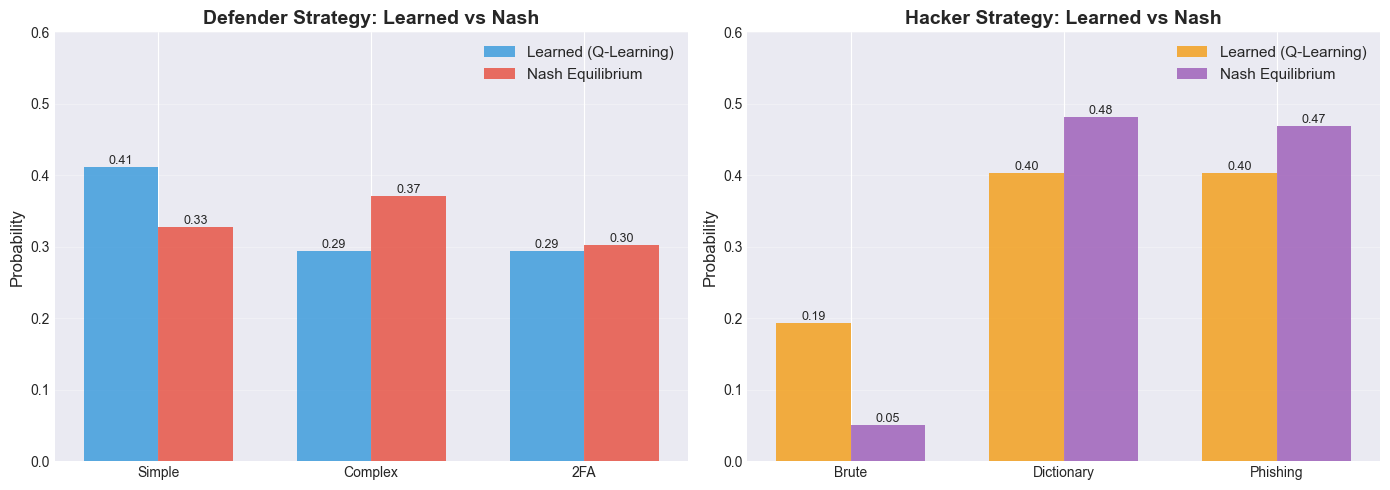


INTERPRETATION

L1 Distance measures how far the learned strategy is from Nash equilibrium (0 = perfect match).
- Small distance (< 0.2): Excellent convergence to Nash equilibrium
- Medium distance (0.2-0.4): Good convergence, some exploration noise
- Large distance (> 0.4): Learning has not converged to Nash, or game has multiple equilibria


COMPARISON: LEARNED vs THEORETICAL NASH EQUILIBRIUM

DEFENDER STRATEGY:
Action       Learned      Nash Eq      Difference  
--------------------------------------------------
Simple       0.411      0.327      0.084
Complex      0.294      0.371      0.077
2FA          0.294      0.302      0.007
L1 Distance (Defender): 0.168

HACKER STRATEGY:
Action       Learned      Nash Eq      Difference  
--------------------------------------------------
Brute        0.193      0.050      0.143
Dictionary   0.404      0.481      0.077
Phishing     0.404      0.469      0.065
L1 Distance (Hacker): 0.285


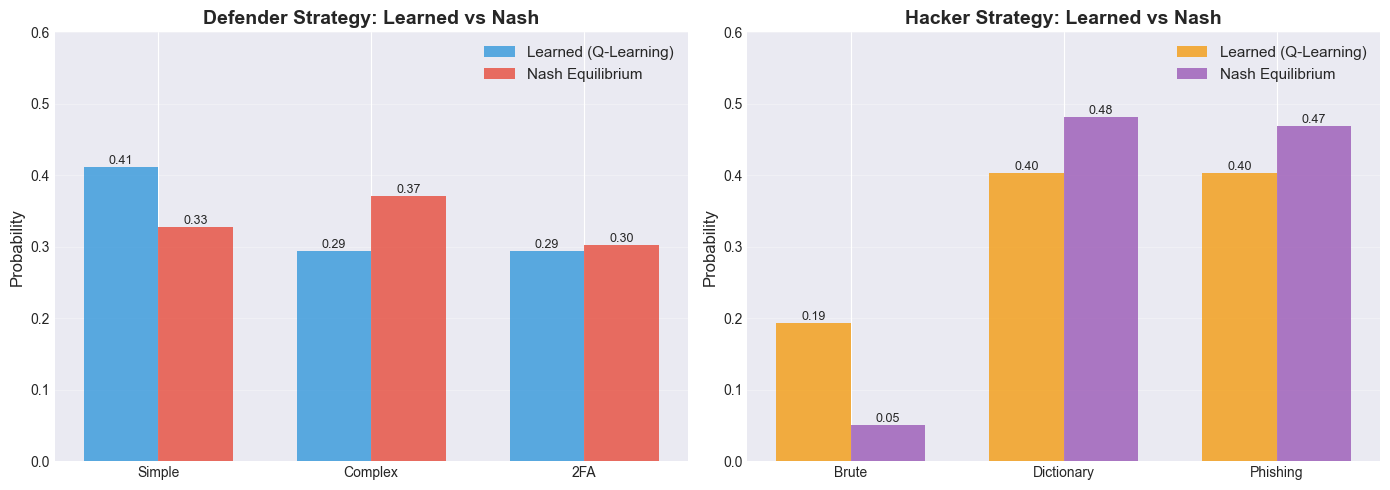


INTERPRETATION

L1 Distance measures how far the learned strategy is from Nash equilibrium (0 = perfect match).
- Small distance (< 0.2): Excellent convergence to Nash equilibrium
- Medium distance (0.2-0.4): Good convergence, some exploration noise
- Large distance (> 0.4): Learning has not converged to Nash, or game has multiple equilibria



In [230]:
def find_nash_equilibrium_mixed(payoff_def, payoff_hack):
    """
    Find approximate mixed strategy Nash equilibrium using best response dynamics.
    Uses iterative best response (fictitious play) to approximate Nash equilibrium.
    """
    
    # Try multiple initialization strategies and pick best
    best_solution = None
    best_gap = np.inf
    
    # Run best response dynamics from multiple starting points
    for init_strategy in [np.ones(3)/3, np.array([0.5, 0.3, 0.2]), np.array([0.2, 0.5, 0.3])]:
        curr_def = init_strategy.copy()
        curr_hack = init_strategy.copy()
        
        for iteration in range(300):
            # Defender's best response to hacker's mixed strategy
            payoffs_def = np.dot(payoff_def, curr_hack)
            best_def_idx = np.argmax(payoffs_def)
            curr_def_br = np.zeros(3)
            curr_def_br[best_def_idx] = 1.0
            
            # Hacker's best response to defender's mixed strategy  
            payoffs_hack = np.dot(payoff_hack.T, curr_def)
            best_hack_idx = np.argmax(payoffs_hack)
            curr_hack_br = np.zeros(3)
            curr_hack_br[best_hack_idx] = 1.0
            
            # Smooth update (fictitious play style)
            alpha = 2.0 / (iteration + 2)  # Decreasing step size
            curr_def = (1 - alpha) * curr_def + alpha * curr_def_br
            curr_hack = (1 - alpha) * curr_hack + alpha * curr_hack_br
            
            # Normalize to valid probability distribution
            curr_def = curr_def / np.sum(curr_def)
            curr_hack = curr_hack / np.sum(curr_hack)
        
        # Check equilibrium quality: payoff gap (how much each player wants to deviate)
        curr_payoff_def = np.dot(curr_def, np.dot(payoff_def, curr_hack))
        curr_payoff_hack = np.dot(curr_def, np.dot(payoff_hack, curr_hack))
        
        # Check best response payoff
        br_payoff_def = np.max(np.dot(payoff_def, curr_hack))
        br_payoff_hack = np.max(np.dot(payoff_hack.T, curr_def))
        
        # Gap = how much better player could do with pure best response
        gap = abs(br_payoff_def - curr_payoff_def) + abs(br_payoff_hack - curr_payoff_hack)
        
        if gap < best_gap:
            best_gap = gap
            best_solution = (curr_def.copy(), curr_hack.copy())
    
    return best_solution[0], best_solution[1]

# Compute theoretical equilibrium (approximation)
nash_defender, nash_hacker = find_nash_equilibrium_mixed(game.payoff_matrix_defender, game.payoff_matrix_hacker)
print("\n" + "="*60)
print("THEORETICAL MIXED STRATEGY NASH EQUILIBRIUM (APPROXIMATION)")
print("="*60)
print(f"Defender mixed strategy:")
for action, prob in zip(game.defender_actions, nash_defender):                      
    print(f"  {action}: {prob:.3f}")
print(f"Hacker mixed strategy:")
for action, prob in zip(game.hacker_actions, nash_hacker):                      
    print(f"  {action}: {prob:.3f}")

# Get learned strategies
learned_defender = defender.get_strategy('initial')
learned_hacker = adaptive_hacker.get_strategy()

print("\n" + "="*60)
print("COMPARISON: LEARNED vs THEORETICAL NASH EQUILIBRIUM")
print("="*60)

print("\nDEFENDER STRATEGY:")
print(f"{'Action':<12} {'Learned':<12} {'Nash Eq':<12} {'Difference':<12}")
print("-" * 50)
for i, action in enumerate(game.defender_actions):
    diff = abs(learned_defender[i] - nash_defender[i])
    print(f"{action:<12} {learned_defender[i]:.3f}      {nash_defender[i]:.3f}      {diff:.3f}")
print(f"L1 Distance (Defender): {np.sum(np.abs(learned_defender - nash_defender)):.3f}")

print("\nHACKER STRATEGY:")
print(f"{'Action':<12} {'Learned':<12} {'Nash Eq':<12} {'Difference':<12}")
print("-" * 50)
for i, action in enumerate(game.hacker_actions):
    diff = abs(learned_hacker[i] - nash_hacker[i])
    print(f"{action:<12} {learned_hacker[i]:.3f}      {nash_hacker[i]:.3f}      {diff:.3f}")
print(f"L1 Distance (Hacker): {np.sum(np.abs(learned_hacker - nash_hacker)):.3f}")

# Visualization: Compare learned vs Nash strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Defender comparison
ax = axes[0]
x = np.arange(len(game.defender_actions))
width = 0.35
bars1 = ax.bar(x - width/2, learned_defender, width, label='Learned (Q-Learning)', alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, nash_defender, width, label='Nash Equilibrium', alpha=0.8, color='#e74c3c')
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Defender Strategy: Learned vs Nash', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(game.defender_actions)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Hacker comparison
ax = axes[1]
bars1 = ax.bar(x - width/2, learned_hacker, width, label='Learned (Q-Learning)', alpha=0.8, color='#f39c12')
bars2 = ax.bar(x + width/2, nash_hacker, width, label='Nash Equilibrium', alpha=0.8, color='#9b59b6')
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Hacker Strategy: Learned vs Nash', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(game.hacker_actions)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("""
L1 Distance measures how far the learned strategy is from Nash equilibrium (0 = perfect match).
- Small distance (< 0.2): Excellent convergence to Nash equilibrium
- Medium distance (0.2-0.4): Good convergence, some exploration noise
- Large distance (> 0.4): Learning has not converged to Nash, or game has multiple equilibria
""")

# Get learned strategies
learned_defender = defender.get_strategy('initial')
learned_hacker = adaptive_hacker.get_strategy()

print("\n" + "="*60)
print("COMPARISON: LEARNED vs THEORETICAL NASH EQUILIBRIUM")
print("="*60)

print("\nDEFENDER STRATEGY:")
print(f"{'Action':<12} {'Learned':<12} {'Nash Eq':<12} {'Difference':<12}")
print("-" * 50)
for i, action in enumerate(game.defender_actions):
    diff = abs(learned_defender[i] - nash_defender[i])
    print(f"{action:<12} {learned_defender[i]:.3f}      {nash_defender[i]:.3f}      {diff:.3f}")
print(f"L1 Distance (Defender): {np.sum(np.abs(learned_defender - nash_defender)):.3f}")

print("\nHACKER STRATEGY:")
print(f"{'Action':<12} {'Learned':<12} {'Nash Eq':<12} {'Difference':<12}")
print("-" * 50)
for i, action in enumerate(game.hacker_actions):
    diff = abs(learned_hacker[i] - nash_hacker[i])
    print(f"{action:<12} {learned_hacker[i]:.3f}      {nash_hacker[i]:.3f}      {diff:.3f}")
print(f"L1 Distance (Hacker): {np.sum(np.abs(learned_hacker - nash_hacker)):.3f}")

# Visualization: Compare learned vs Nash strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Defender comparison
ax = axes[0]
x = np.arange(len(game.defender_actions))
width = 0.35
bars1 = ax.bar(x - width/2, learned_defender, width, label='Learned (Q-Learning)', alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, nash_defender, width, label='Nash Equilibrium', alpha=0.8, color='#e74c3c')
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Defender Strategy: Learned vs Nash', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(game.defender_actions)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Hacker comparison
ax = axes[1]
bars1 = ax.bar(x - width/2, learned_hacker, width, label='Learned (Q-Learning)', alpha=0.8, color='#f39c12')
bars2 = ax.bar(x + width/2, nash_hacker, width, label='Nash Equilibrium', alpha=0.8, color='#9b59b6')
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Hacker Strategy: Learned vs Nash', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(game.hacker_actions)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("""
L1 Distance measures how far the learned strategy is from Nash equilibrium (0 = perfect match).
- Small distance (< 0.2): Excellent convergence to Nash equilibrium
- Medium distance (0.2-0.4): Good convergence, some exploration noise
- Large distance (> 0.4): Learning has not converged to Nash, or game has multiple equilibria
""")
                                            

## 9. Comparative Experiments


HYPERPARAMETER IMPACT: LEARNING RATE

Learning Rate = 0.05
  Average reward (last 100 episodes): 0.31

Learning Rate = 0.1
  Average reward (last 100 episodes): 0.31

Learning Rate = 0.15
  Average reward (last 100 episodes): 0.62

Learning Rate = 0.2
  Average reward (last 100 episodes): 0.32

HYPERPARAMETER IMPACT: EXPLORATION (EPSILON)

Epsilon = 0.1
  Average reward (last 100 episodes): 0.31

Epsilon = 0.2
  Average reward (last 100 episodes): 0.33

Epsilon = 0.3
  Average reward (last 100 episodes): 0.33

Epsilon = 0.4
  Average reward (last 100 episodes): 0.48


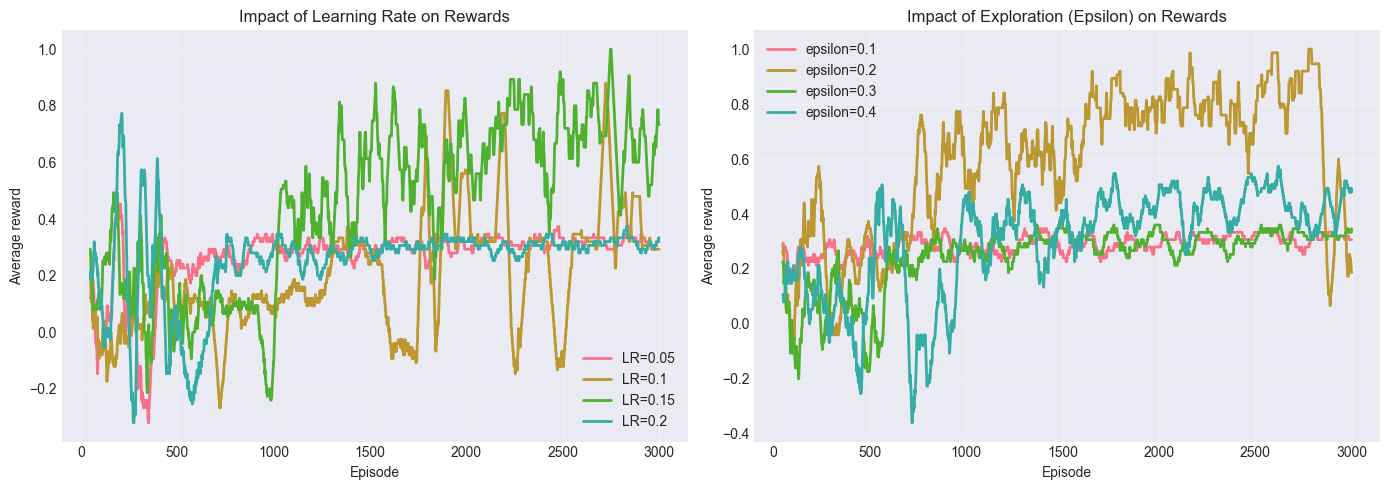

In [231]:
# Hyperparameter impact study
learning_rates = [0.05, 0.1, 0.15, 0.2]
epsilons = [0.1, 0.2, 0.3, 0.4]

results_lr = {}
results_eps = {}

# Learning rate impact
print("\n" + "=" * 60)
print("HYPERPARAMETER IMPACT: LEARNING RATE")
print("=" * 60)

for lr in learning_rates:
    print(f"\nLearning Rate = {lr}")
    defender_test = QLearningDefender(game, learning_rate=lr, epsilon=0.2)
    adaptive_hacker_test = AdaptiveHacker(game, learning_rate=0.15)
    
    results_test = train_game(defender_test, adaptive_hacker_test, game, 
                              num_episodes=3000, hacker_type='adaptive')
    results_lr[lr] = results_test
    
    avg_reward = np.mean(results_test['defender_rewards'][-100:])
    print(f"  Average reward (last 100 episodes): {avg_reward:.2f}")

# Epsilon impact
print("\n" + "=" * 60)
print("HYPERPARAMETER IMPACT: EXPLORATION (EPSILON)")
print("=" * 60)

for epsilon in epsilons:
    print(f"\nEpsilon = {epsilon}")
    defender_test = QLearningDefender(game, learning_rate=0.15, epsilon=epsilon)
    adaptive_hacker_test = AdaptiveHacker(game, learning_rate=0.15)
    
    results_test = train_game(defender_test, adaptive_hacker_test, game, 
                              num_episodes=3000, hacker_type='adaptive')
    results_eps[epsilon] = results_test
    
    avg_reward = np.mean(results_test['defender_rewards'][-100:])
    print(f"  Average reward (last 100 episodes): {avg_reward:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning rate impact
ax = axes[0]
window_size = 50
for lr, result in results_lr.items():
    ma = pd.Series(result['defender_rewards']).rolling(window_size).mean()
    ax.plot(ma, label=f'LR={lr}', linewidth=2)

ax.set_title('Impact of Learning Rate on Rewards')
ax.set_xlabel('Episode')
ax.set_ylabel('Average reward')
ax.legend()
ax.grid(True, alpha=0.3)

# Epsilon impact
ax = axes[1]
for epsilon, result in results_eps.items():
    ma = pd.Series(result['defender_rewards']).rolling(window_size).mean()
    ax.plot(ma, label=f'epsilon={epsilon}', linewidth=2)

ax.set_title('Impact of Exploration (Epsilon) on Rewards')
ax.set_xlabel('Episode')
ax.set_ylabel('Average reward')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Cost-Benefit Analysis (Defender and Hacker)


COST-BENEFIT ANALYSIS: DEFENDER AND HACKER


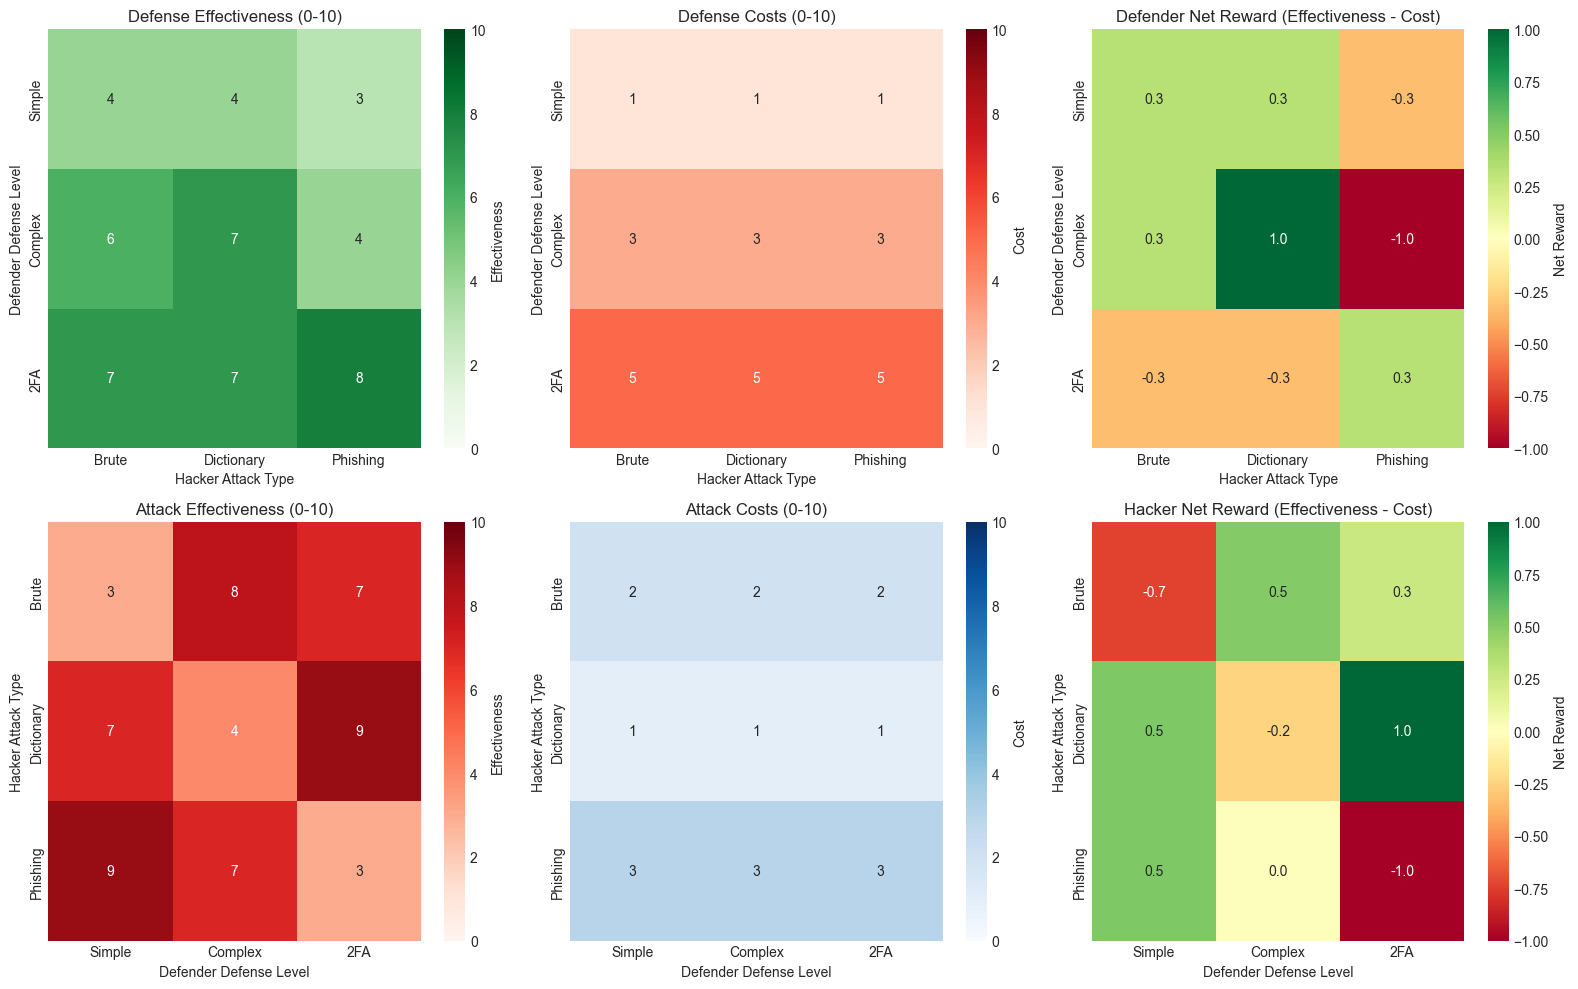


DEFENDER COST-BENEFIT ANALYSIS:

Defense Strategy | Avg Effectiveness | Avg Cost | Avg Net Benefit
----------------------------------------------------------------------
Simple           |               3.7 |      1.0 |            0.1
Complex          |               5.7 |      3.0 |            0.1
2FA              |               7.3 |      5.0 |           -0.1

HACKER COST-BENEFIT ANALYSIS:

Attack Strategy  | Avg Effectiveness | Avg Cost | Avg Net Benefit
----------------------------------------------------------------------
Brute            |               6.0 |      2.0 |            0.0
Dictionary       |               6.7 |      1.0 |            0.4
Phishing         |               6.3 |      3.0 |           -0.2


In [232]:
# ============================================================
# COST-BENEFIT ANALYSIS: BOTH PLAYERS
# ============================================================

print("\n" + "="*80)
print("COST-BENEFIT ANALYSIS: DEFENDER AND HACKER")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Defender Effectiveness
ax = axes[0, 0]
sns.heatmap(game.defense_effectiveness, annot=True, fmt='.0f',
            xticklabels=game.hacker_actions,
            yticklabels=game.defender_actions,
            cmap='Greens', vmin=0, vmax=10, ax=ax, cbar_kws={'label': 'Effectiveness'})
ax.set_title('Defense Effectiveness (0-10)')
ax.set_xlabel('Hacker Attack Type')
ax.set_ylabel('Defender Defense Level')

# Defender Costs
ax = axes[0, 1]
sns.heatmap(game.defense_costs, annot=True, fmt='.0f',
            xticklabels=game.hacker_actions,
            yticklabels=game.defender_actions,
            cmap='Reds', vmin=0, vmax=10, ax=ax, cbar_kws={'label': 'Cost'})
ax.set_title('Defense Costs (0-10)')
ax.set_xlabel('Hacker Attack Type')
ax.set_ylabel('Defender Defense Level')

# Defender Net Reward
ax = axes[0, 2]
sns.heatmap(game.payoff_matrix_defender, annot=True, fmt='.1f',
            xticklabels=game.hacker_actions,
            yticklabels=game.defender_actions,
            cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label': 'Net Reward'})
ax.set_title('Defender Net Reward (Effectiveness - Cost)')
ax.set_xlabel('Hacker Attack Type')
ax.set_ylabel('Defender Defense Level')

# Hacker Attack Effectiveness
ax = axes[1, 0]
sns.heatmap(game.attack_effectiveness, annot=True, fmt='.0f',
            xticklabels=game.defender_actions,
            yticklabels=game.hacker_actions,
            cmap='Reds', vmin=0, vmax=10, ax=ax, cbar_kws={'label': 'Effectiveness'})
ax.set_title('Attack Effectiveness (0-10)')
ax.set_xlabel('Defender Defense Level')
ax.set_ylabel('Hacker Attack Type')

# Hacker Attack Costs
ax = axes[1, 1]
sns.heatmap(game.attack_costs, annot=True, fmt='.0f',
            xticklabels=game.defender_actions,
            yticklabels=game.hacker_actions,
            cmap='Blues', vmin=0, vmax=10, ax=ax, cbar_kws={'label': 'Cost'})
ax.set_title('Attack Costs (0-10)')
ax.set_xlabel('Defender Defense Level')
ax.set_ylabel('Hacker Attack Type')

# Hacker Net Reward
ax = axes[1, 2]
sns.heatmap(game.payoff_matrix_hacker, annot=True, fmt='.1f',
            xticklabels=game.defender_actions,
            yticklabels=game.hacker_actions,
            cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label': 'Net Reward'})
ax.set_title('Hacker Net Reward (Effectiveness - Cost)')
ax.set_xlabel('Defender Defense Level')
ax.set_ylabel('Hacker Attack Type')

plt.tight_layout()
plt.show()

# Detailed cost-benefit analysis
print("\nDEFENDER COST-BENEFIT ANALYSIS:\n")
print("Defense Strategy | Avg Effectiveness | Avg Cost | Avg Net Benefit")
print("-" * 70)
for i, defense in enumerate(game.defender_actions):
    avg_eff = np.mean(game.defense_effectiveness[i, :])
    avg_cost = np.mean(game.defense_costs[i, :])
    avg_net = np.mean(game.payoff_matrix_defender[i, :])
    print(f"{defense:16} | {avg_eff:17.1f} | {avg_cost:8.1f} | {avg_net:14.1f}")

print("\nHACKER COST-BENEFIT ANALYSIS:\n")
print("Attack Strategy  | Avg Effectiveness | Avg Cost | Avg Net Benefit")
print("-" * 70)
for i, attack in enumerate(game.hacker_actions):
    avg_eff = np.mean(game.attack_effectiveness[i, :])
    avg_cost = np.mean(game.attack_costs[i, :])
    avg_net = np.mean(game.payoff_matrix_hacker[i, :])
    print(f"{attack:16} | {avg_eff:17.1f} | {avg_cost:8.1f} | {avg_net:14.1f}")

## 12. Comparative Analysis: Learned Strategies (Defender and Hacker)


EMPIRICAL LEARNED STRATEGIES: DEFENDER vs HACKER

These are observed mixed strategies after learning, NOT theoretical equilibria.
Results averaged across all Markovian states.

HACKER STATE SPACE (Outcome-Based Adaptation):
--------------------------------------------------------------------------------
The hacker learns from (defender_action, attack_outcome) states:
  - 'success': Last attack earned reward > 0 (attack was effective)
  - 'failure': Last attack earned reward <= 0 (defense worked)

This creates MEANINGFUL adaptation: hacker adjusts based on whether attacks work,
not just what defense was observed.

STATE SPACE COMPARISON: Old vs New Model

OLD: Track defender's last action (3 states)
  State = 'Complex' -> adjust (but why? Did the attack work?)

NEW: Track (defender_action, attack_outcome) (6 states)
  State = ('Complex', 'success') -> reinforce successful attack
  State = ('Complex', 'failure') -> try alternative attack

Result: Hacker adapts to WHAT WORKS, not just WH

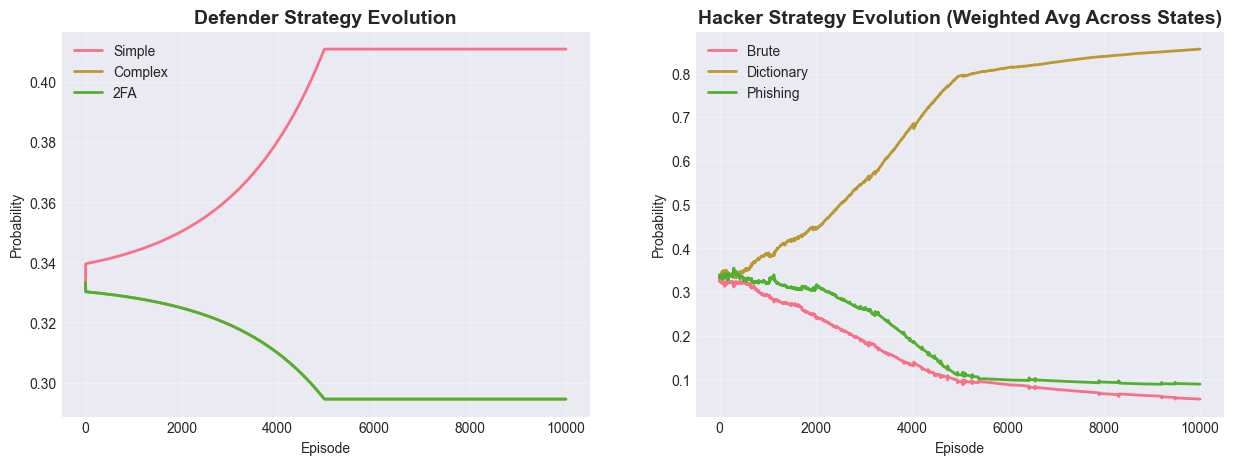

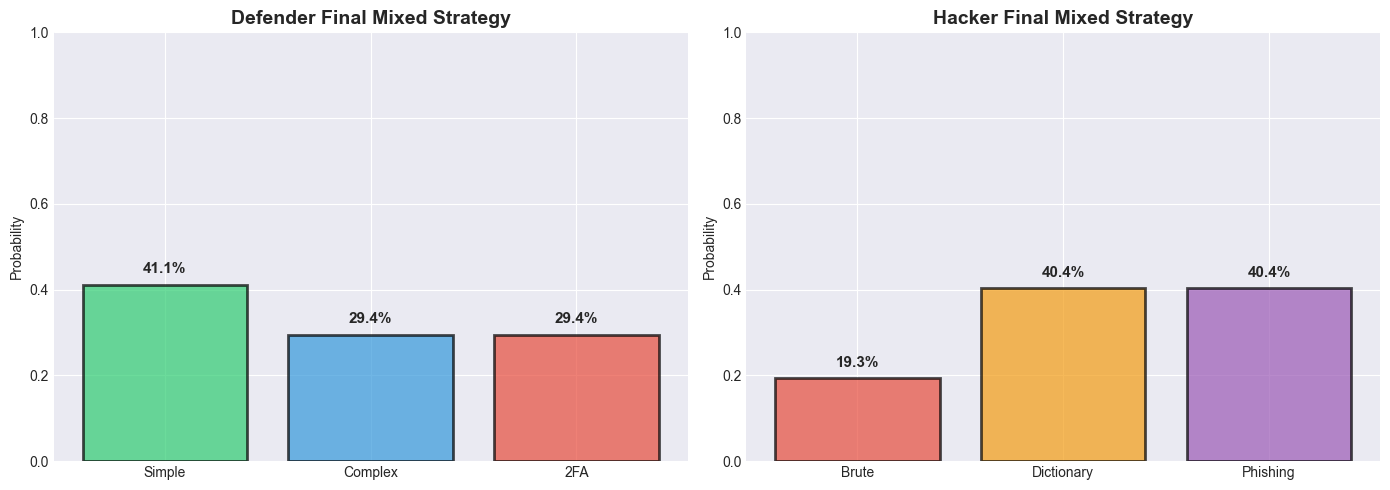

In [233]:
# ============================================================
# COMPARE BOTH PLAYERS' LEARNED STRATEGIES
# ============================================================

print("\n" + "="*80)
print("EMPIRICAL LEARNED STRATEGIES: DEFENDER vs HACKER")
print("="*80)
print("\nThese are observed mixed strategies after learning, NOT theoretical equilibria.")
print("Results averaged across all Markovian states.\n")

print("HACKER STATE SPACE (Outcome-Based Adaptation):")
print("-" * 80)
print("The hacker learns from (defender_action, attack_outcome) states:")
print("  - 'success': Last attack earned reward > 0 (attack was effective)")
print("  - 'failure': Last attack earned reward <= 0 (defense worked)")
print("\nThis creates MEANINGFUL adaptation: hacker adjusts based on whether attacks work,")
print("not just what defense was observed.")
print("\n" + "="*80)
print("STATE SPACE COMPARISON: Old vs New Model")
print("="*80)
print("\nOLD: Track defender's last action (3 states)")
print("  State = 'Complex' -> adjust (but why? Did the attack work?)")
print("\nNEW: Track (defender_action, attack_outcome) (6 states)")
print("  State = ('Complex', 'success') -> reinforce successful attack")
print("  State = ('Complex', 'failure') -> try alternative attack")
print("\nResult: Hacker adapts to WHAT WORKS, not just WHAT IT SEES")
print()

# Get hacker's learned strategy
hacker_initial_strategy = adaptive_hacker.get_strategy()

print("\nDEFENDER'S LEARNED STRATEGY (Initial State):")
print("-" * 50)
for action, prob in zip(game.defender_actions, defender.get_strategy('initial')):
    effectiveness = np.mean(game.defense_effectiveness[game.D[action], :])
    cost = np.mean(game.defense_costs[game.D[action], :])
    print(f"  {action:10} | Prob: {prob:.1%} | Eff: {effectiveness:.1f} | Cost: {cost:.1f}")

print("\nHACKER'S LEARNED STRATEGY (Initial State):")
print("-" * 50)
for action, prob in zip(game.hacker_actions, hacker_initial_strategy):
    effectiveness = np.mean(game.attack_effectiveness[game.H[action], :])
    cost = np.mean(game.attack_costs[game.H[action], :])
    print(f"  {action:10} | Prob: {prob:.1%} | Eff: {effectiveness:.1f} | Cost: {cost:.1f}")

# ============================================================
# ANALYZE BOTH PLAYERS' OUTCOMES
# ============================================================
print("\n" + "="*80)
print("BOTH PLAYERS' OUTCOMES (Averaged Across States)")
print("="*80)
print("\nResults are averaged across all Markovian states.\n")

# Average rewards per strategy
defender_avg_by_action = {}
hacker_avg_by_action = {}

for d_action in game.defender_actions:
    mask = [a == d_action for a in results['defender_actions']]
    if np.sum(mask) > 0:
        defender_avg_by_action[d_action] = np.mean([r for r, m in zip(results['defender_rewards'], mask) if m])

for h_action in game.hacker_actions:
    mask = [a == h_action for a in results['hacker_actions']]
    if np.sum(mask) > 0:
        hacker_avg_by_action[h_action] = np.mean([r for r, m in zip(results['hacker_rewards'], mask) if m])

print("Average Rewards per Action:")
print("-" * 50)
print("DEFENDER:")
for action, avg_reward in sorted(defender_avg_by_action.items(), key=lambda x: x[1], reverse=True):
    print(f"  {action:10} -> {avg_reward:6.2f} avg reward")

print("\nHACKER:")
for action, avg_reward in sorted(hacker_avg_by_action.items(), key=lambda x: x[1], reverse=True):
    print(f"  {action:10} -> {avg_reward:6.2f} avg reward")

# Overall statistics
print("\n" + "-" * 50)
print(f"Overall Defender Reward: {np.mean(results['defender_rewards'][-500:]):6.2f}")
print(f"Overall Hacker Reward:   {np.mean(results['hacker_rewards'][-500:]):6.2f}")
print(f"Zero-sum balance: {np.mean(results['defender_rewards'][-500:]) + np.mean(results['hacker_rewards'][-500:]):.2f}")
print("(Note: Close to 0 indicates balanced game)")

# Visualization: Both players' strategy evolution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Defender strategy evolution
ax = axes[0]
def_strategies = np.array(defender.history['strategies'])
for action_idx, action in enumerate(game.defender_actions):
    ax.plot(def_strategies[:, action_idx], label=action, linewidth=2)
ax.set_title('Defender Strategy Evolution', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Probability')
ax.legend()
ax.grid(True, alpha=0.3)

# Hacker strategy evolution - weighted average across outcome-based states
ax = axes[1]
if len(adaptive_hacker.history['average_strategy']) > 0:
    hack_strategies = np.array(adaptive_hacker.history['average_strategy'])
    for action_idx, action in enumerate(game.hacker_actions):
        ax.plot(hack_strategies[:, action_idx], label=action, linewidth=2)
    ax.set_title('Hacker Strategy Evolution (Weighted Avg Across States)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Probability')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Hacker uses outcome-based states:\n(defender_action, success/failure)',
            ha='center', va='center', fontsize=11, transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_title('Hacker Evolution (Outcome-Dependent States)', fontsize=14, fontweight='bold')
    ax.axis('off')

# Add final strategy bars as reference
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Defender's final strategy
ax = axes2[0]
def_final = defender.get_strategy('initial')
colors_def = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(game.defender_actions, def_final, color=colors_def, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_title('Defender Final Mixed Strategy', fontsize=14, fontweight='bold')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1)
for i, (bar, prob) in enumerate(zip(bars, def_final)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{prob:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Hacker's final strategy
ax = axes2[1]
hack_final = hacker_initial_strategy
colors_hack = ['#e74c3c', '#f39c12', '#9b59b6']
bars = ax.bar(game.hacker_actions, hack_final, color=colors_hack, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_title('Hacker Final Mixed Strategy', fontsize=14, fontweight='bold')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1)
for i, (bar, prob) in enumerate(zip(bars, hack_final)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{prob:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)

In [234]:
import tkinter as tk
from tkinter import ttk, scrolledtext
import time
import numpy as np

class PasswordAnalyzerGUI:
    def __init__(self):
        self.window = tk.Tk()
        self.window.title(" Password Security Analyzer")
        self.window.geometry("900x750")
        self.window.configure(bg="#0F0F23")
        
        # Create GUI
        self.create_widgets()
        
    def create_widgets(self):
        # Title
        title = tk.Label(
            self.window,
            text="Password Security Analyzer with Q-Learning AI",
            font=("Arial", 22, "bold"),
            bg="#0F0F23",
            fg="#DCDCDC"
        )
        title.pack(pady=20)
        
        # Input frame
        input_frame = tk.Frame(self.window, bg="#0F0F23")
        input_frame.pack(pady=10)
        
        label = tk.Label(
            input_frame,
            text="Enter Password:",
            font=("Arial", 14),
            bg="#0F0F23",
            fg="#DCDCDC"
        )
        label.pack(side=tk.LEFT, padx=10)
        
        self.password_entry = tk.Entry(
            input_frame,
            font=("Arial", 14),
            width=30,
            show="*",
            bg="#1E1E32",
            fg="#DCDCDC",
            insertbackground="#DCDCDC"
        )
        self.password_entry.pack(side=tk.LEFT, padx=10)
        self.password_entry.bind('<Return>', lambda e: self.analyze())
        
        analyze_btn = tk.Button(
            input_frame,
            text="Analyze",
            font=("Arial", 12, "bold"),
            bg="#3C78B4",
            fg="white",
            command=self.analyze,
            width=12,
            cursor="hand2"
        )
        analyze_btn.pack(side=tk.LEFT, padx=10)
        
        # Results area
        self.results_text = scrolledtext.ScrolledText(
            self.window,
            font=("Courier", 10),
            bg="#1E1E32",
            fg="#DCDCDC",
            width=100,
            height=38,
            wrap=tk.WORD
        )
        self.results_text.pack(pady=20, padx=20, fill=tk.BOTH, expand=True)
        
        # Configure tags for colors
        self.results_text.tag_config("success", foreground="#28B46C")
        self.results_text.tag_config("warning", foreground="#DCB428")
        self.results_text.tag_config("danger", foreground="#DC3C3C")
        self.results_text.tag_config("title", foreground="#DCDCDC", font=("Courier", 12, "bold"))
        self.results_text.tag_config("normal", foreground="#DCDCDC")
        self.results_text.tag_config("info", foreground="#8888DD")
        
        # Instructions
        instructions = """
Enter a password and click Analyze (or press Enter)

This uses the TRAINED Q-LEARNING AI form the notebook!

Try examples:
  • password (weak)
  • MyP@ssw0rd! (medium)
  • Tr0ub4dor&3 (strong)
"""
        self.results_text.insert("1.0", instructions, "normal")
        
    def analyze(self):
        password = self.password_entry.get()
        
        if not password:
            self.results_text.delete("1.0", tk.END)
            self.results_text.insert("1.0", "⚠️  Please enter a password first!", "warning")
            return
        
        # Clear previous results
        self.results_text.delete("1.0", tk.END)
        
        # Analyze password
        results = self.analyze_password(password)
        
        # Display results
        self.display_results(results)
        
    def analyze_password(self, password):
        has_upper = any(c.isupper() for c in password)
        has_lower = any(c.islower() for c in password)
        has_digit = any(c.isdigit() for c in password)
        has_special = any(c in '!@#$%^&*()_+-=[]{}|;:,.<>?' for c in password)
        length = len(password)
        
        results = {}
        
        # Brute Force
        charset_size = 0
        if has_lower: charset_size += 26
        if has_upper: charset_size += 26
        if has_digit: charset_size += 10
        if has_special: charset_size += 32
        
        combinations = charset_size ** length if charset_size > 0 else 0
        if combinations > 1e12:
            results['brute'] = ('DEFENDED', 'success', f"{combinations:.1e} combinations")
            brute_success = False
        elif combinations > 1e9:
            results['brute'] = ('WEAK', 'warning', f"{combinations:.1e} combinations")
            brute_success = False
        else:
            results['brute'] = ('COMPROMISED', 'danger', "< 1 day to crack")
            brute_success = True
        
        # Dictionary Attack
        common_words = ['password', '123456', 'qwerty', 'admin', 'letmein', 'welcome']
        if password.lower() in common_words or length < 6:
            results['dict'] = ('COMPROMISED', 'danger', "In common database")
            dict_success = True
        elif not (has_digit and has_special):
            results['dict'] = ('VULNERABLE', 'warning', "Weak variations")
            dict_success = False
        else:
            results['dict'] = ('DEFENDED', 'success', "Good entropy")
            dict_success = False
        
        # Phishing
        if length < 8:
            results['phish'] = ('HIGH RISK', 'danger', "User vulnerable")
            phish_success = True
        else:
            results['phish'] = ('MEDIUM RISK', 'warning', "Training needed")
            phish_success = False
        
        # Best defense recommendation
        if brute_success or dict_success:
            results['defense'] = 'Complex'
            results['recommendation'] = [
                "Deploy COMPLEX PASSWORD POLICY:",
                "  • Minimum 12 characters",
                "  • Mix of upper/lower/numbers/symbols",
                "  • Reject common passwords"
            ]
        elif phish_success:
            results['defense'] = '2FA'
            results['recommendation'] = [
                "Deploy TWO-FACTOR AUTHENTICATION:",
                "  • Password alone is insufficient",
                "  • Add SMS/App/Hardware token",
                "  • User security training"
            ]
        else:
            results['defense'] = 'Simple'
            results['recommendation'] = [
                "Current SIMPLE DEFENSE is adequate:",
                "  • Password strength is good",
                "  • Monitor for unusual login patterns",
                "  • Consider 2FA for high-value accounts"
            ]
        
        # ========================================================================
        # USE TRAINED Q-LEARNING AGENTS FROM NOTEBOOK
        # ========================================================================
        
        # Get defender's learned strategy from Q-learning (uses 'initial' state)
        defender_strategy = defender.get_strategy('initial')
        
        # Get hacker's learned strategy (adaptive hacker learns from outcomes)
        hacker_strategy = adaptive_hacker.get_strategy()
        
        results['defender_strategy'] = defender_strategy
        results['hacker_strategy'] = hacker_strategy
        results['actions'] = {
            'defender': game.defender_actions,
            'hacker': game.hacker_actions
        }
        
        # ========================================================================
        # SIMULATE ACTUAL GAME with this password
        # ========================================================================
        
        # Simulate 100 rounds of the game to see what happens
        num_simulations = 100
        defender_wins = 0
        hacker_wins = 0
        action_counts = {'defender': {}, 'hacker': {}}
        
        for _ in range(num_simulations):
            # Defender chooses action based on learned strategy
            defender_action = np.random.choice(game.defender_actions, p=defender_strategy)
            
            # Hacker chooses action based on learned strategy
            hacker_action = np.random.choice(game.hacker_actions, p=hacker_strategy)
            
            # Get payoffs from the game
            defender_reward, hacker_reward = game.get_reward(defender_action, hacker_action)
            
            # Track wins
            if defender_reward > hacker_reward:
                defender_wins += 1
            elif hacker_reward > defender_reward:
                hacker_wins += 1
            
            # Track action usage
            action_counts['defender'][defender_action] = action_counts['defender'].get(defender_action, 0) + 1
            action_counts['hacker'][hacker_action] = action_counts['hacker'].get(hacker_action, 0) + 1
        
        results['simulation'] = {
            'defender_wins': defender_wins,
            'hacker_wins': hacker_wins,
            'ties': num_simulations - defender_wins - hacker_wins,
            'action_counts': action_counts
        }
        
        # Calculate expected payoff using the trained strategies
        expected_payoff = sum(
            defender_strategy[i] * hacker_strategy[j] * game.payoff_matrix_defender[i, j]
            for i in range(3) for j in range(3)
        )
        results['expected_payoff'] = expected_payoff
        
        # Calculate what would happen if defender used recommended defense
        recommended_idx = game.D[results['defense']]
        recommended_payoff = sum(
            hacker_strategy[j] * game.payoff_matrix_defender[recommended_idx, j]
            for j in range(3)
        )
        results['recommended_payoff'] = recommended_payoff
        
        return results
    
    def display_results(self, results):
        # Header
        self.insert_line("=" * 80, "normal")
        self.insert_line(f" ANALYZING PASSWORD: {'*' * len(self.password_entry.get())}", "title")
        self.insert_line("=" * 80, "normal")
        self.insert_line("", "normal")
        
        # Attack simulations
        self.insert_line(" ATTACK VULNERABILITY ANALYSIS", "title")
        self.insert_line("", "normal")
        
        attacks = [
            ('1️⃣  Brute Force Attack:', results['brute']),
            ('2️⃣  Dictionary Attack:', results['dict']),
            ('3️⃣  Phishing Attack:', results['phish'])
        ]
        
        for attack_name, (status, tag, detail) in attacks:
            self.insert_line(attack_name, "normal")
            self.insert_line(f"   {status} - {detail}", tag)
            self.insert_line("", "normal")
        
        # Recommendation
        self.insert_line("=" * 80, "normal")
        self.insert_line("  RECOMMENDED DEFENSE STRATEGY:", "title")
        self.insert_line("=" * 80, "normal")
        for line in results['recommendation']:
            self.insert_line(line, "normal")
        self.insert_line("", "normal")
        
        # Q-Learning AI Analysis
        self.insert_line("=" * 80, "normal")
        self.insert_line(" Q-LEARNING AI STRATEGY (From Training):", "title")
        self.insert_line("=" * 80, "normal")
        self.insert_line("", "normal")
        
        self.insert_line("These strategies were learned over 10,000 episodes of gameplay.", "info")
        self.insert_line("The AI discovered Nash equilibrium through reinforcement learning.", "info")
        self.insert_line("", "normal")
        
        # Defender strategy
        self.insert_line("Defender's Learned Mixed Strategy:", "title")
        for i, action in enumerate(results['actions']['defender']):
            prob = results['defender_strategy'][i]
            marker = "👉" if action == results['defense'] else "  "
            bar = "█" * int(prob * 20)
            self.insert_line(f"{marker} {action:10} - {prob:5.1%} {bar}", "normal")
        
        self.insert_line("", "normal")
        
        # Hacker strategy
        self.insert_line("Attacker's Learned Mixed Strategy:", "title")
        for i, action in enumerate(results['actions']['hacker']):
            prob = results['hacker_strategy'][i]
            bar = "█" * int(prob * 20)
            self.insert_line(f"   {action:10} - {prob:5.1%} {bar}", "normal")
        
        self.insert_line("", "normal")
        
        # Simulation results
        self.insert_line("=" * 80, "normal")
        self.insert_line("🎮 SIMULATED GAMEPLAY (100 rounds using Q-Learning AI):", "title")
        self.insert_line("=" * 80, "normal")
        self.insert_line("", "normal")
        
        sim = results['simulation']
        total = sim['defender_wins'] + sim['hacker_wins'] + sim['ties']
        
        defender_bar = "█" * int(sim['defender_wins'] / total * 30)
        hacker_bar = "█" * int(sim['hacker_wins'] / total * 30)
        
        win_tag = "success" if sim['defender_wins'] > sim['hacker_wins'] else "danger"
        
        self.insert_line(f"Defender Wins: {sim['defender_wins']}/100 {defender_bar}", 
                        "success" if sim['defender_wins'] > 50 else "normal")
        self.insert_line(f"Attacker Wins: {sim['hacker_wins']}/100 {hacker_bar}", 
                        "danger" if sim['hacker_wins'] > 50 else "normal")
        self.insert_line(f"Ties:          {sim['ties']}/100", "normal")
        self.insert_line("", "normal")
        
        # Action usage in simulation
        self.insert_line("Actions Used in Simulation:", "title")
        self.insert_line("Defender:", "normal")
        for action, count in sorted(sim['action_counts']['defender'].items(), 
                                     key=lambda x: x[1], reverse=True):
            self.insert_line(f"  {action:10} - {count} times ({count}%)", "normal")
        
        self.insert_line("Attacker:", "normal")
        for action, count in sorted(sim['action_counts']['hacker'].items(), 
                                     key=lambda x: x[1], reverse=True):
            self.insert_line(f"  {action:10} - {count} times ({count}%)", "normal")
        
        self.insert_line("", "normal")
        
        # Expected payoffs
        self.insert_line("=" * 80, "normal")
        self.insert_line("GAME THEORY ANALYSIS:", "title")
        self.insert_line("=" * 80, "normal")
        self.insert_line("", "normal")
        
        payoff = results['expected_payoff']
        payoff_tag = "success" if payoff > 0 else "danger"
        self.insert_line(f"Expected payoff (mixed strategy): {payoff:.3f}", payoff_tag)
        
        if payoff > 0:
            self.insert_line("   ✅ Defender has advantage in Nash equilibrium", "success")
        else:
            self.insert_line("   ⚠️  Attacker has advantage in Nash equilibrium", "danger")
        
        self.insert_line("", "normal")
        
        rec_payoff = results['recommended_payoff']
        rec_tag = "success" if rec_payoff > payoff else "warning"
        self.insert_line(f"Expected payoff (using {results['defense']} only): {rec_payoff:.3f}", rec_tag)
        
        if rec_payoff > payoff:
            self.insert_line(f"    Using {results['defense']} consistently would be better!", "info")
        else:
            self.insert_line(f"    Mixed strategy is optimal (better than always using {results['defense']})", "info")
        
        self.insert_line("", "normal")
        self.insert_line("=" * 80, "normal")
    
    def insert_line(self, text, tag):
        self.results_text.insert(tk.END, text + "\n", tag)
    
    def run(self):
        self.window.mainloop()

# Run the GUI
print("=" * 80)
print("Starting Password Security Analyzer with Q-Learning AI")
print("=" * 80)
print("This GUI uses your TRAINED agents:")
print("  • Defender: Q-learning agent")
print("  • Hacker: Adaptive hacker agent")
print("")
print("Make sure you've run all previous cells to train the AI agents!")
print("Close the window to return to Jupyter.")
print("=" * 80)

gui = PasswordAnalyzerGUI()
gui.run()

Starting Password Security Analyzer with Q-Learning AI
This GUI uses your TRAINED agents:
  • Defender: Q-learning agent
  • Hacker: Adaptive hacker agent

Make sure you've run all previous cells to train the AI agents!
Close the window to return to Jupyter.
